In [1]:
library(Signac)
library(Seurat)
library(ggplot2)
library(dplyr)
library(BuenColors)
library(SeuratData)
library(tibble)
library(GenomeInfoDb)
library(tidyr)
library(jsonlite)
library(stringr)
library(EnsDb.Mmusculus.v79)
library(Banksy)
library(cowplot)
library(spacexr)
library(ComplexHeatmap)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: MASS


Attaching package: ‘MASS’


The following object is masked from ‘package:dplyr’:

    select


── Installed datasets ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────── SeuratData v0.2.2 ──

✔ stxBrain 0.1.1                                                                                                       


───────────────────────────────────────────────────────────────────────────────────────────────────────────────────── Key ──────

In [2]:
# Set up multithreading for faster processing

library(future)
plan("multicore", workers = 16)


Attaching package: 'future'


The following object is masked from 'package:AnnotationFilter':

    value




In [3]:
# Set working directory; change this to your local directory if you are running the code locally

setwd('/gpfs/commons/groups/vickovic_lab/rhe/projects/005/space_tag_reproducibility/fig1')

#### Figure 1b: Compare SPACE-Tag data with existing methods

In [4]:
public_data_fragment_files <- c(
  'processed_data/public-data/GSM5028434_deng_H3K27me3_frags.tsv.gz',
  'processed_data/public-data/GSM5028435_deng_H3K4me3_frags.tsv.gz',
  'processed_data/public-data/GSM5028436_deng_H3K27ac_frags.tsv.gz',
  'processed_data/public-data/GSM6704978_zhang_H3K27me3_frags.tsv.gz',
  'processed_data/public-data/GSM6704979_zhang_H3K27ac_frags.tsv.gz',
  'processed_data/public-data/GSM6704980_zhang_H3K4me3_frags.tsv.gz',
  'processed_data/public-data/GSM8189708_guo_H3K4me3_frags.tsv.gz',
  'processed_data/public-data/GSM8189711_guo_H3K27ac_frags.tsv.gz',
  'processed_data/public-data/GSM8579950_huang_frags_reprocessed.tsv.gz',
  'processed_data/public-data/GSM6619661_llorens_bobadilla_frags.tsv.gz')


public_data_sample_names <- c(
  'deng_H3K27me3',
  'deng_H3K4me3',
  'deng_H3K27ac',
  'zhang_H3K27me3',
  'zhang_H3K27ac',
  'zhang_H3K4me3',
  'guo_H3K4me3',
  'guo_H3K27ac',
  'huang_atac',
  'llorens-bobadilla_atac')

In [5]:
space_tag_fragment_files <- c(
  'processed_data/space-tag/GSM9580164_space_tag_H3K27me3_frags.bed.gz',
  'processed_data/space-tag/GSM9580159_space_tag_H3K4me3_frags.bed.gz',
  'processed_data/space-tag/GSM9580171_space_tag_H3K27ac_frags.bed.gz'
)

space_tag_sample_names <- c(
  'space-tag_H3K27me3',
  'space-tag_H3K4me3',
  'space-tag_H3K27ac')

##### Generate a Signac object with 10kb genomic tiles for each dataset

In [6]:
objs_list <- list()

In [7]:
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Mmusculus.v79)
seqlevelsStyle(annotations) <- 'UCSC'
annotations <- keepStandardChromosomes(annotations, pruning.mode="coarse")
genome(annotations) <- "mm10"

mm10_seqinfo <- GenomeInfoDb::seqinfo(EnsDb.Mmusculus.v79)
GenomeInfoDb::seqlevelsStyle(mm10_seqinfo) <- "UCSC"
mm10_seqinfo <- GenomeInfoDb::keepSeqlevels(
  mm10_seqinfo,
  GenomeInfoDb::standardChromosomes(mm10_seqinfo),
  pruning.mode = "coarse"
)

tile_features <- GenomicRanges::tileGenome(
  seqlengths = GenomeInfoDb::seqlengths(mm10_seqinfo),
  tilewidth = 10000,
  cut.last.tile.in.chrom = TRUE
)

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [8]:
all_fragment_files <- c(public_data_fragment_files, space_tag_fragment_files)
all_sample_names <- c(public_data_sample_names, space_tag_sample_names)

for (i in seq_along(all_fragment_files)) {
  sample_name <- all_sample_names[i]
  frag_path <- all_fragment_files[i]

  frag_obj <- Signac::CreateFragmentObject(
    path = frag_path,
    validate.fragments = FALSE
  )

  tile_counts <- Signac::FeatureMatrix(
    fragments = frag_obj,
    features = tile_features
  )

  chrom_assay <- Signac::CreateChromatinAssay(
    counts = tile_counts,
    fragments = frag_obj
  )

  objs_list[[sample_name]] <- Seurat::CreateSeuratObject(
    counts = chrom_assay,
    assay = "tiles",
    project = sample_name
  )

  total_fragments <- CountFragments(Fragments(objs_list[[sample_name]])[[1]]@path)
  total_fragments <- column_to_rownames(total_fragments, 'CB')
  objs_list[[sample_name]]@meta.data[['total_fragments']] <- total_fragments[WhichCells(objs_list[[sample_name]]), 'frequency_count']
}

Computing hash



Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Extracting reads overlapping genomic regions



In [9]:
frags_df <- data.frame(sample = character(), n_frags = numeric(), manuscript = character(), modality = character())

for (sample_name in names(objs_list)) {
  n_frags <- objs_list[[sample_name]]@meta.data$total_fragments

  manuscript <- str_split(sample_name, "_")[[1]][1]
  modality <- str_split(sample_name, "_")[[1]][2]
  
  frags_df <- rbind(frags_df, data.frame(sample = sample_name, n_frags = n_frags, manuscript = manuscript, modality = modality))
}

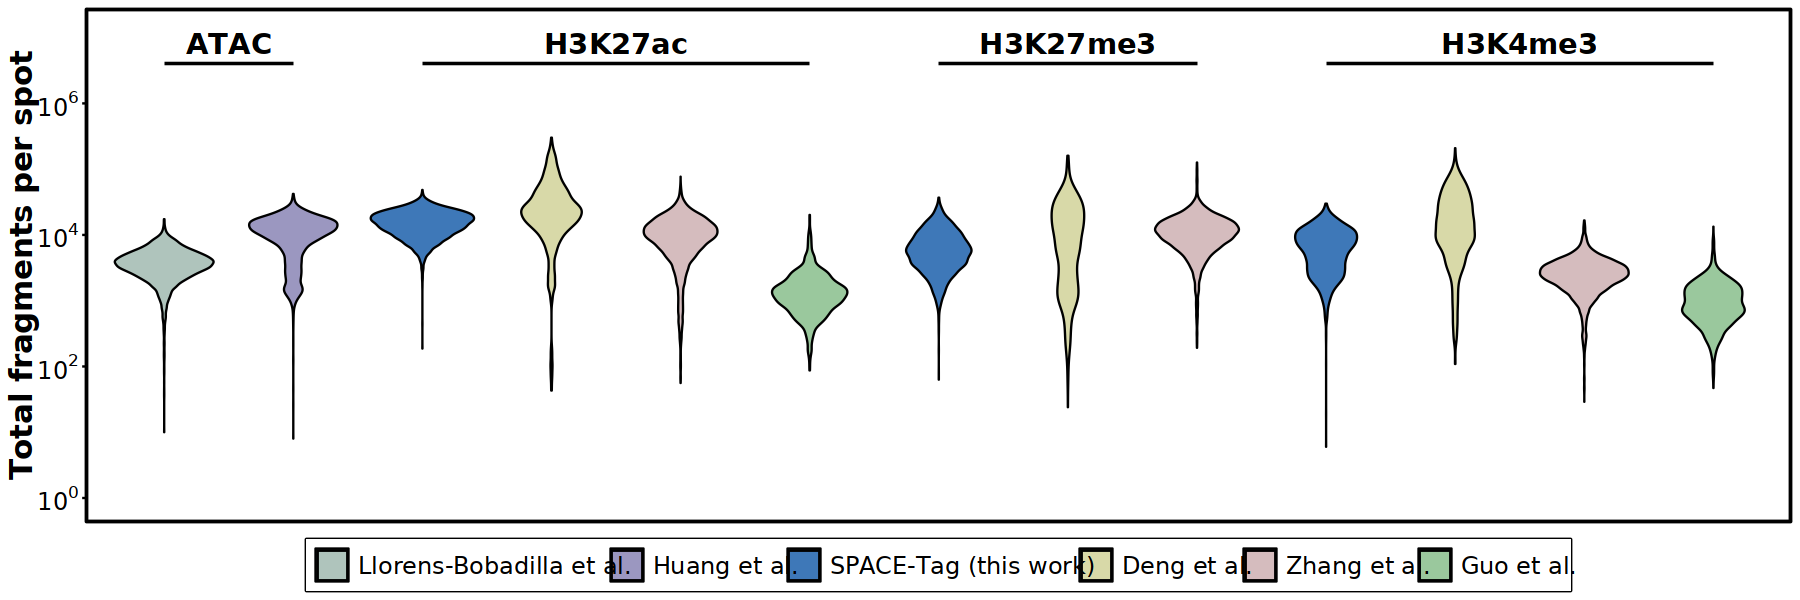

In [10]:
plot_df <- frags_df %>%
  mutate(
    modality = case_when(
      str_to_lower(modality) %in% c("atac") ~ "ATAC",
      str_to_lower(modality) %in% c("h3k27ac") ~ "H3K27ac",
      str_to_lower(modality) %in% c("h3k27me3") ~ "H3K27me3",
      str_to_lower(modality) %in% c("h3k4me3") ~ "H3K4me3",
      TRUE ~ modality
    ),
    manuscript = case_when(
      manuscript %in% c("llorens-bobadilla", "llorens_bobadilla") ~ "Llorens-Bobadilla et al.",
      manuscript == "huang" ~ "Huang et al.",
      manuscript == "space-tag" ~ "SPACE-Tag (this work)",
      manuscript == "deng" ~ "Deng et al.",
      manuscript == "zhang" ~ "Zhang et al.",
      manuscript == "guo" ~ "Guo et al.",
      TRUE ~ manuscript
    )
  )

sample_order <- c(
  "llorens-bobadilla_atac", "huang_atac", 
  "space-tag_H3K27ac", "deng_H3K27ac", "zhang_H3K27ac", "guo_H3K27ac",
  "space-tag_H3K27me3","deng_H3K27me3", "zhang_H3K27me3", 
  "space-tag_H3K4me3", "deng_H3K4me3", "zhang_H3K4me3", "guo_H3K4me3"
)

plot_df <- plot_df %>%
  dplyr::filter(sample %in% sample_order) %>%
  mutate(sample = factor(sample, levels = sample_order))

manuscript_colors <- c(
  "Llorens-Bobadilla et al." = "#AFC4BC",
  "Huang et al." = "#9B97C0",
  "SPACE-Tag (this work)" = "#3E78B8",
  "Deng et al." = "#D8D9A8",
  "Zhang et al." = "#D5BCBE",
  "Guo et al." = "#9AC89D"
)

group_positions <- list(
  ATAC = c(1, 2),
  H3K27ac = c(3, 6),
  H3K27me3 = c(7, 9),
  H3K4me3 = c(10, 13)
)

y_top <- 4e6
y_bottom <- 1

options(repr.plot.width = 15, repr.plot.height = 5)
p <- ggplot(plot_df, aes(x = sample, y = n_frags, fill = manuscript)) +
  geom_violin(width = 0.8, color = "black", linewidth = 0.5, trim = TRUE) +
  scale_fill_manual(values = manuscript_colors, breaks = names(manuscript_colors), drop = FALSE) +
  scale_y_log10(
    breaks = c(1, 1e2, 1e4, 1e6),
    labels = scales::label_math(10^.x, format = log10)
  ) +
  coord_cartesian(ylim = c(y_bottom, y_top*3), clip = "off") +
  labs(x = NULL, y = "Total fragments per spot", fill = NULL) +
  annotate("segment", x = group_positions$ATAC[1], xend = group_positions$ATAC[2], y = y_top, yend = y_top, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K27ac[1], xend = group_positions$H3K27ac[2], y = y_top, yend = y_top, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K27me3[1], xend = group_positions$H3K27me3[2], y = y_top, yend = y_top, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K4me3[1], xend = group_positions$H3K4me3[2], y = y_top, yend = y_top, linewidth = 0.75) +
  annotate("text", x = mean(group_positions$ATAC), y = y_top * 2, label = "ATAC", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K27ac), y = y_top * 2, label = "H3K27ac", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K27me3), y = y_top * 2, label = "H3K27me3", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K4me3), y = y_top * 2, label = "H3K4me3", fontface = "bold", size = 6) +
  theme_classic() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_text(face = "bold", size = 18),
    axis.text.y = element_text(size = 14),
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.8),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box.background = element_rect(color = "black", fill = "white", linewidth = 0.8),
    legend.key = element_rect(fill = "white", color = "black"),
    legend.key.size = unit(0.7, "cm"),
    legend.text = element_text(size = 14),
  ) +
  guides(fill = guide_legend(nrow = 1, byrow = TRUE, override.aes = list(linewidth = 0.6)))
print(p)
options(repr.plot.width = 7, repr.plot.height = 7)

#### Figure S3: Frip scores

In [11]:
for (sample_name in names(objs_list)) {
  frag_path <- Fragments(objs_list[[sample_name]])[[1]]@path  
  new_peaks <- CallPeaks(objs_list[[sample_name]], combine.peaks = TRUE, broad = TRUE, additional.args = '--slocal 5000 --llocal 50000 --max-gap 1000', macs2.path = '/gpfs/commons/home/rhe/.conda/envs/spatial_multiome/bin/macs2')
  
  frags <- CreateFragmentObject(
    path = frag_path,
    validate.fragments = FALSE,
    cells = WhichCells(objs_list[[sample_name]])
  )

  new_mtx <- FeatureMatrix(
    fragments = frags,
    features = new_peaks,
    cells = WhichCells(objs_list[[sample_name]])
  )

  objs_list[[sample_name]][['new_assay']] <- CreateChromatinAssay(
    counts = new_mtx,
    fragments = frag_path,
    annotation = annotations
  )

  objs_list[[sample_name]]@meta.data$frip <- objs_list[[sample_name]]@meta.data$nCount_new_assay / objs_list[[sample_name]]@meta.data$total_fragments
}

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Computing hash

Computing hash

Extracting reads overlapping genomic regions

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Computing hash

Computing hash

Extracting reads overlapping genomic regions

Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Warning message:
"Feature names cannot have underscores ('_'), replacing with dashes ('-')"
Computing hash

Computin

In [12]:
frip_df <- data.frame(sample = character(), frip = numeric(), manuscript = character(), modality = character())

for (sample_name in names(objs_list)) {
  frip <- objs_list[[sample_name]]@meta.data$frip

  manuscript <- str_split(sample_name, "_")[[1]][1]
  modality <- str_split(sample_name, "_")[[1]][2]
  
  frip_df <- rbind(frip_df, data.frame(sample = sample_name, frip = frip, manuscript = manuscript, modality = modality))
}

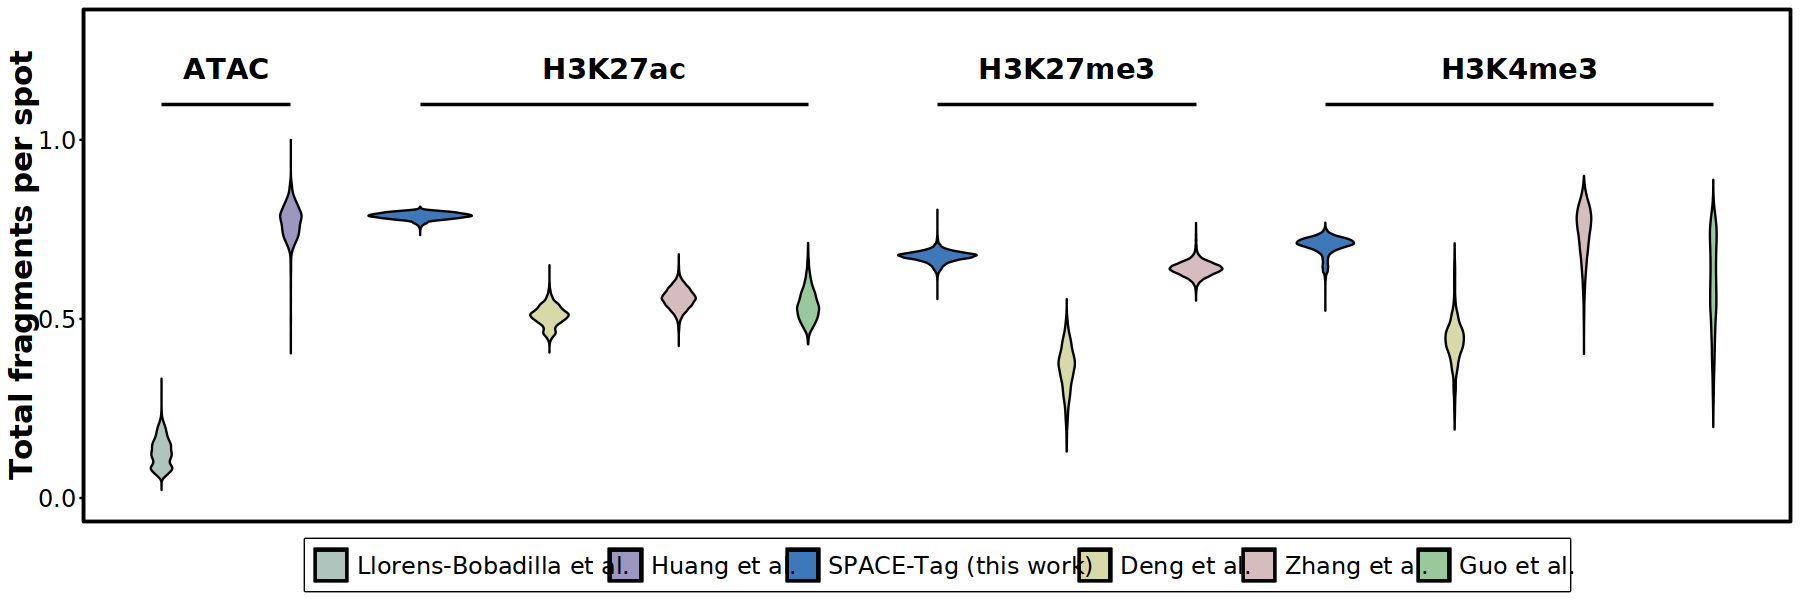

In [15]:
plot_df <- frip_df %>%
  mutate(
    modality = case_when(
      str_to_lower(modality) %in% c("atac") ~ "ATAC",
      str_to_lower(modality) %in% c("h3k27ac") ~ "H3K27ac",
      str_to_lower(modality) %in% c("h3k27me3") ~ "H3K27me3",
      str_to_lower(modality) %in% c("h3k4me3") ~ "H3K4me3",
      TRUE ~ modality
    ),
    manuscript = case_when(
      manuscript %in% c("llorens-bobadilla", "llorens_bobadilla") ~ "Llorens-Bobadilla et al.",
      manuscript == "huang" ~ "Huang et al.",
      manuscript == "space-tag" ~ "SPACE-Tag (this work)",
      manuscript == "deng" ~ "Deng et al.",
      manuscript == "zhang" ~ "Zhang et al.",
      manuscript == "guo" ~ "Guo et al.",
      TRUE ~ manuscript
    )
  )

sample_order <- c(
  "llorens-bobadilla_atac", "huang_atac", 
  "space-tag_H3K27ac", "deng_H3K27ac", "zhang_H3K27ac", "guo_H3K27ac",
  "space-tag_H3K27me3","deng_H3K27me3", "zhang_H3K27me3", 
  "space-tag_H3K4me3", "deng_H3K4me3", "zhang_H3K4me3", "guo_H3K4me3"
)

plot_df <- plot_df %>%
  dplyr::filter(sample %in% sample_order) %>%
  mutate(sample = factor(sample, levels = sample_order))

manuscript_colors <- c(
  "Llorens-Bobadilla et al." = "#AFC4BC",
  "Huang et al." = "#9B97C0",
  "SPACE-Tag (this work)" = "#3E78B8",
  "Deng et al." = "#D8D9A8",
  "Zhang et al." = "#D5BCBE",
  "Guo et al." = "#9AC89D"
)

group_positions <- list(
  ATAC = c(1, 2),
  H3K27ac = c(3, 6),
  H3K27me3 = c(7, 9),
  H3K4me3 = c(10, 13)
)

y_top <- 1
y_bottom <- 0

options(repr.plot.width = 15, repr.plot.height = 5)
p <- ggplot(plot_df, aes(x = sample, y = frip, fill = manuscript)) +
  geom_violin(width = 0.8, color = "black", linewidth = 0.5, trim = TRUE) +
  scale_fill_manual(values = manuscript_colors, breaks = names(manuscript_colors), drop = FALSE) +
  coord_cartesian(ylim = c(y_bottom, y_top*1.3), clip = "off") +
  labs(x = NULL, y = "Total fragments per spot", fill = NULL) +
  annotate("segment", x = group_positions$ATAC[1], xend = group_positions$ATAC[2], y = y_top*1.1, yend = y_top*1.1, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K27ac[1], xend = group_positions$H3K27ac[2], y = y_top*1.1, yend = y_top*1.1, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K27me3[1], xend = group_positions$H3K27me3[2], y = y_top*1.1, yend = y_top*1.1, linewidth = 0.75) +
  annotate("segment", x = group_positions$H3K4me3[1], xend = group_positions$H3K4me3[2], y = y_top*1.1, yend = y_top*1.1, linewidth = 0.75) +
  annotate("text", x = mean(group_positions$ATAC), y = y_top * 1.2, label = "ATAC", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K27ac), y = y_top * 1.2, label = "H3K27ac", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K27me3), y = y_top * 1.2, label = "H3K27me3", fontface = "bold", size = 6) +
  annotate("text", x = mean(group_positions$H3K4me3), y = y_top * 1.2, label = "H3K4me3", fontface = "bold", size = 6) +
  theme_classic() +
  theme(
    axis.text.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.title.y = element_text(face = "bold", size = 18),
    axis.text.y = element_text(size = 14),
    panel.border = element_rect(fill = NA, color = "black", linewidth = 0.8),
    legend.position = "bottom",
    legend.direction = "horizontal",
    legend.box.background = element_rect(color = "black", fill = "white", linewidth = 0.8),
    legend.key = element_rect(fill = "white", color = "black"),
    legend.key.size = unit(0.7, "cm"),
    legend.text = element_text(size = 14),
  ) +
  guides(fill = guide_legend(nrow = 1, byrow = TRUE, override.aes = list(linewidth = 0.6)))
print(p)
options(repr.plot.width = 7, repr.plot.height = 7)